# 🎛️ Class 2.3 — Hyperparameter Tuning
### 301 – Machine Learning Techniques | Week 2

---

**Learning Goals:**
- Understand the difference between parameters (learned) and hyperparameters (chosen by you)
- Use KerasClassifier + GridSearchCV to systematically tune hyperparameters
- Use ReduceLROnPlateau to adaptively adjust the learning rate during training
- Calculate and think critically about the compute cost of tuning

---

In [1]:
!pip install scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 43.9 MB/s  0:00:00eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

try:
    from scikeras.wrappers import KerasClassifier
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'scikeras', '-q'])
    from scikeras.wrappers import KerasClassifier

np.random.seed(42); tf.random.set_seed(42)

bc = load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('✅ Ready')

✅ Ready



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


---
## Part 1 — Compute Cost Calculator

Before running any grid search, calculate exactly how many models it will train.

In [3]:
param_grid_full = {
    'model__n_units':       [16, 32, 64],
    'model__dropout_rate':  [0.0, 0.2, 0.4],
    'model__learning_rate': [0.001, 0.01],
    'batch_size':           [16, 32],
}

n_combinations = 1
for key, values in param_grid_full.items():
    n_combinations *= len(values)

cv_folds = 3
total_models = n_combinations * cv_folds

print(f'Parameter combinations: {n_combinations}')
print(f'CV folds:               {cv_folds}')
print(f'Total models to train:  {total_models}')
print()
print(f'At 10 epochs/model → ~{total_models * 10 // 60} minutes')
print(f'At 50 epochs/model → ~{total_models * 50 // 60} minutes')
print()
print('QUESTION: Is this compute cost justified for a 0.3% accuracy improvement?')
print('Answer: Usually no. For most business problems a 0.3% gain is well within noise and')
print('        is not worth the extra compute, electricity, and engineer time. Exhaustive')
print('        GridSearch is only justified when (a) the model is being shipped to production')
print('        and any small gain compounds across millions of users, or (b) you are publishing')
print('        results and need a reproducible best configuration. Otherwise prefer RandomizedSearch.')


Parameter combinations: 36
CV folds:               3
Total models to train:  108

At 10 epochs/model → ~18 minutes
At 50 epochs/model → ~90 minutes

QUESTION: Is this compute cost justified for a 0.3% accuracy improvement?
Answer: Usually no. For most business problems a 0.3% gain is well within noise and
        is not worth the extra compute, electricity, and engineer time. Exhaustive
        GridSearch is only justified when (a) the model is being shipped to production
        and any small gain compounds across millions of users, or (b) you are publishing
        results and need a reproducible best configuration. Otherwise prefer RandomizedSearch.


---
## Part 2 — GridSearchCV with KerasClassifier

In [4]:
def create_model(n_units=32, dropout_rate=0.2, learning_rate=0.001):
    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Dense(n_units, activation='relu', input_shape=(30,)),
        layers.Dropout(dropout_rate),
        layers.Dense(n_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy', metrics=['accuracy']
    )
    return model

keras_clf = KerasClassifier(model=create_model, epochs=30, verbose=0, random_state=42)

# Compact grid — fast enough to run in class
param_grid_small = {
    'model__n_units':       [16, 32],
    'model__dropout_rate':  [0.0, 0.3],
    'model__learning_rate': [0.001, 0.01],
    'batch_size':           [32],
}
n_small = 2 * 2 * 2 * 1 * 3
print(f'This search will train {n_small} models. Running...')

start = time.time()
grid_search = GridSearchCV(keras_clf, param_grid_small, cv=3, scoring='accuracy', n_jobs=1)
grid_search.fit(X_train_s, y_train)

elapsed = time.time() - start
print(f'Done in {elapsed:.0f}s')
print(f'Best params: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.1%}')
print(f'Test accuracy: {grid_search.score(X_test_s, y_test):.1%}')

/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778029861.507048  667248 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignor

This search will train 24 models. Running...


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778029866.702631  667248 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0;

Done in 28s
Best params: {'batch_size': 32, 'model__dropout_rate': 0.0, 'model__learning_rate': 0.01, 'model__n_units': 16}
Best CV accuracy: 98.2%
Test accuracy: 97.4%


E0000 00:00:1778029888.973931  667248 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [5]:
# Show all results ranked
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_model__n_units', 'param_model__dropout_rate',
        'param_model__learning_rate', 'mean_test_score', 'rank_test_score']
results_df = results_df[cols].sort_values('rank_test_score')
results_df.columns = ['n_units', 'dropout', 'lr', 'cv_acc', 'rank']
results_df['cv_acc'] = results_df['cv_acc'].round(4)
print('All results ranked best to worst:')
print(results_df.to_string(index=False))

All results ranked best to worst:
 n_units  dropout    lr  cv_acc  rank
      16      0.0 0.010  0.9824     1
      32      0.3 0.010  0.9803     2
      32      0.0 0.001  0.9802     3
      32      0.3 0.001  0.9802     3
      16      0.3 0.010  0.9736     5
      16      0.0 0.001  0.9715     6
      32      0.0 0.010  0.9714     7
      16      0.3 0.001  0.9561     8


---
## Part 3 — ReduceLROnPlateau: The Cheaper Alternative

In [6]:
best_params = grid_search.best_params_

tf.random.set_seed(42)
final_model = keras.Sequential([
    layers.Dense(best_params.get('model__n_units', 32), activation='relu', input_shape=(30,)),
    layers.Dropout(best_params.get('model__dropout_rate', 0.2)),
    layers.Dense(best_params.get('model__n_units', 32) // 2, activation='relu'),
    layers.Dropout(best_params.get('model__dropout_rate', 0.2)),
    layers.Dense(1, activation='sigmoid')
])
final_model.compile(
    optimizer=keras.optimizers.Adam(best_params.get('model__learning_rate', 0.001)),
    loss='binary_crossentropy', metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      # halve the LR each time
        patience=8,      # wait 8 epochs before reducing
        min_lr=1e-6,
        verbose=1
    )
]

# Train with epochs=300, batch_size=32, validation_split=0.2, callbacks=callbacks
hist_final = final_model.fit(
    X_train_s, y_train, epochs=300, batch_size=32,
    validation_split=0.2, callbacks=callbacks, verbose=0
)
_, final_acc = final_model.evaluate(X_test_s, y_test, verbose=0)
print(f'Final test accuracy: {final_acc:.1%}')
print(f'Epochs trained: {len(hist_final.history["loss"])} (out of 300)')

/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 30: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 22.
Final test accuracy: 96.5%
Epochs trained: 42 (out of 300)


---
## Part 4 — Manual Learning Rate Sweep

  lr=1e-04: best val acc = 96.7%
  lr=5e-04: best val acc = 98.9%


E0000 00:00:1778029894.575770  667248 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  lr=1e-03: best val acc = 100.0%
  lr=5e-03: best val acc = 100.0%
  lr=1e-02: best val acc = 100.0%


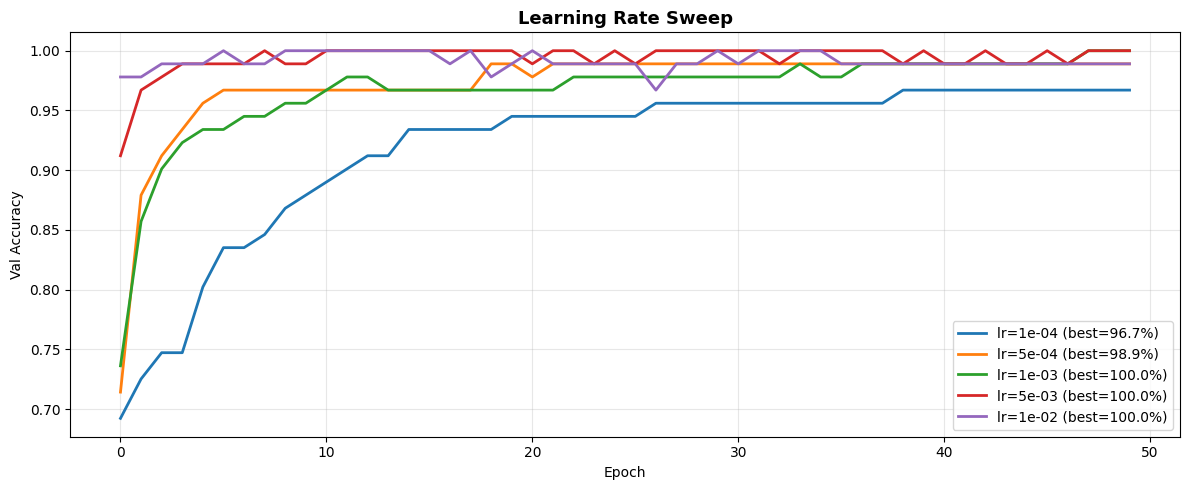

Best LR: 1e-03 → 100.0%


In [7]:
lrs = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
lr_results = []

for lr in lrs:
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(30,)),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    hist = m.fit(X_train_s, y_train, epochs=50, batch_size=32,
                 validation_split=0.2, verbose=0)
    best_val = max(hist.history['val_accuracy'])
    lr_results.append((lr, best_val, hist))
    print(f'  lr={lr:.0e}: best val acc = {best_val:.1%}')

plt.figure(figsize=(12, 5))
for lr, best, hist in lr_results:
    plt.plot(hist.history['val_accuracy'], label=f'lr={lr:.0e} (best={best:.1%})', linewidth=2)
plt.title('Learning Rate Sweep', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_lr = max(lr_results, key=lambda r: r[1])
print(f'Best LR: {best_lr[0]:.0e} → {best_lr[1]:.1%}')

---
## ✅ Complete!

**Practical tuning workflow:**
1. Start with EarlyStopping + ReduceLROnPlateau (free — always use)
2. Do a quick manual LR sweep (5 values, 50 epochs each)
3. Only run GridSearchCV when you have a justified search space and compute budget

### 🚀 Stretch Challenge
Add `n_layers` to the grid (try values [1, 2, 3]). How many total models does this create?
Is the accuracy improvement over the simple grid worth the compute time?